# Aerodynamics and rotor

AeroSandbox AeroBuildup and the Scholz hand build-up on the baseline design, hover download and the blown
wing; the JVX-calibrated proprotor; and the simple aerodynamic model that is kept as the fastest option.

In [1]:
import sys
import time
import warnings
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
for path in (repo_root / "src", repo_root):     # this checkout's package even if another one is installed
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))
warnings.filterwarnings("ignore", category=FutureWarning)

import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

check_log = []


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua, yellow = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})

## 1. Aerodynamics on the baseline design

*From `tier21_aerodynamics/aerodynamics_verification.ipynb`.* The models are compared without the drag corrections.

In [2]:
import sys
import time
from dataclasses import replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
for path in (repo_root / "src", repo_root):     # this checkout's package even if another one is installed
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import aerosandbox as asb
import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

from aircraft_closure.aerodynamics.buildup import BuildupAerodynamics
from aircraft_closure.aerodynamics.download import HoverDownload, download_fraction
from aircraft_closure.aerodynamics.scholz import (InterferenceFactors, ScholzAerodynamics, form_factor_nacelle,
                                                  oswald_nita_scholz, skin_friction_turbulent)
from aircraft_closure.aerodynamics.slipstream import BlownWing, RotorState
from examples.halo_sizing import (HaloAssumptions, HaloRequirements, build_halo_aerodynamics, build_halo_aircraft,
                                  solve_halo_sizing)
from examples.trajectory_optimization import halo_trajectory_case, solve_min_energy_transition, solve_min_time_climb

# Plan 027 made AeroBuildup the default; this notebook keeps comparing against the plan 026 reference (simple aero).
from functools import partial
from examples.halo_sizing import HaloAssumptions as _HaloAssumptions, solve_halo_sizing as _solve_halo_sizing
HaloAssumptions = partial(_HaloAssumptions, drag_corrections=False, redundancy=False, machine_mass_model="torque_density", gearbox_stages=False,
                          aerodynamics_model="simple", thermal_model=False)
solve_halo_sizing = partial(_solve_halo_sizing, assumptions=HaloAssumptions())
from examples.xv15_reference import Xv15Reference, build_xv15_aircraft

check_log = globals().get("check_log", [])


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


def scalar(x):
    return float(np.asarray(x).ravel()[0])


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua, yellow = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8,
                     "axes.labelcolor": ink, "xtick.color": ink_muted, "ytick.color": ink_muted})
colors = {"simple": ink_muted, "buildup": blue, "scholz": orange}
requirements = HaloRequirements()
models = {m: build_halo_aerodynamics(requirements, replace(HaloAssumptions(), aerodynamics_model=m))
          for m in ("simple", "buildup", "scholz")}

In [3]:
# The baseline design aircraft (every model on), evaluated with each aerodynamic model.
reference = _solve_halo_sizing(assumptions=_HaloAssumptions())
aircraft = build_halo_aircraft(reference.design, requirements, _HaloAssumptions())
print(f"baseline design: {reference.mass_takeoff_kg / u.lbm:,.0f} lb, wing {reference.design.area_wing_m2:.2f} m2, "
      f"span {reference.span_m:.2f} m, rotor R {reference.radius_rotor_m:.2f} m")
check("baseline take-off weight 15,179 lb (+- 20)", abs(reference.mass_takeoff_kg / u.lbm - 15179) < 20)

CasADi - 2026-10-06 02:05:05 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]


reference: 15,179 lb, wing 23.30 m2, span 11.94 m, rotor R 4.83 m
PASS  reference take-off weight 15,179 lb (+- 20)


### 2. Closed-form pieces (Scholz, Korn, Nita-Scholz)

- Turbulent flat plate with Mach (Scholz 13.17): `0.455 / (log10 Re)^2.58 / (1 + 0.144 M^2)^0.65`.
- Raymer nacelle form factor (13.24): `1 + 0.35 / (l/d)`; the Halo nacelles are 9 ft x 3.3 ft.
- Korn with Lock's criterion: `M_DD = 0.87 - t/c - CL/10`, `M_crit = M_DD - (0.1/80)^(1/3)`. The 23 % thick
  NACA 2423 wing at CL 0.6 has `M_crit` about 0.43, above the 210 kt / 10,000 ft Mach of 0.33: no drag rise.
- Nita-Scholz Oswald factor: `e = e_theo k_e,F k_e,D0 k_e,M`.

In [4]:
check("Scholz Cf at M = 0 is 0.455 / (log Re)^2.58",
      abs(scalar(skin_friction_turbulent(1e7, 0.0)) - 0.455 / 7**2.58) < 1e-12)
fineness = HaloAssumptions().length_nacelle_m / HaloAssumptions().diameter_nacelle_m
check(f"Raymer nacelle FF = 1 + 0.35 / {fineness:.2f} = {scalar(form_factor_nacelle(fineness)):.3f}",
      abs(scalar(form_factor_nacelle(fineness)) - (1 + 0.35 / fineness)) < 1e-12)
thickness = aircraft.wing.airfoil.max_thickness()
mach_cruise = scalar(210 * u.knot / asb.Atmosphere(10000 * u.foot).speed_of_sound())
mach_crit = 0.87 - thickness - 0.6 / 10 - (0.1 / 80)**(1 / 3)
print(f"wing t/c {thickness:.3f}; M_crit {mach_crit:.3f} at CL 0.6; M at 210 kt, 10,000 ft {mach_cruise:.3f}")
check("Korn: no wave drag at 210 kt on the 23 % section",
      scalar(models["scholz"].wave_drag_coefficient(aircraft, 0.6, mach_cruise)) == 0.0)
check("Korn: drag rise 20 (M - M_crit)^4 above M_crit",
      abs(scalar(models["scholz"].wave_drag_coefficient(aircraft, 0.6, mach_crit + 0.1)) - 20 * 0.1**4) < 1e-6)
e_halo = scalar(oswald_nita_scholz(1.0, aircraft.wing.aspect_ratio,
                                   aircraft.fuselage.diameter_m / scalar(aircraft.wing.span_m()), 0.25))
print(f"Nita-Scholz e (AR {aircraft.wing.aspect_ratio}, d_F/b {aircraft.fuselage.diameter_m / scalar(aircraft.wing.span_m()):.3f}): {e_halo:.3f}")
check("Nita-Scholz e in the usual 0.7-0.8 band for an unswept AR 6 wing", 0.7 < e_halo < 0.8)

PASS  Scholz Cf at M = 0 is 0.455 / (log Re)^2.58
PASS  Raymer nacelle FF = 1 + 0.35 / 2.73 = 1.128
wing t/c 0.230; M_crit 0.472 at CL 0.6; M at 210 kt, 10,000 ft 0.329
PASS  Korn: no wave drag at 210 kt on the 23 % section
PASS  Korn: drag rise 20 (M - M_crit)^4 above M_crit
Nita-Scholz e (AR 6.12, d_F/b 0.140): 0.737
PASS  Nita-Scholz e in the usual 0.7-0.8 band for an unswept AR 6 wing


### 3. Drag polars at the cruise condition

Polars at 10,000 ft and 150 kt for the three models on the reference geometry. AeroBuildup's lift includes the
tails at zero incidence (no downwash), so it has a higher slope than the wing-only linear models; at a given
CL the drag is the comparable quantity.

simple      3.9 ms per point


buildup    53.7 ms per point
scholz      2.8 ms per point


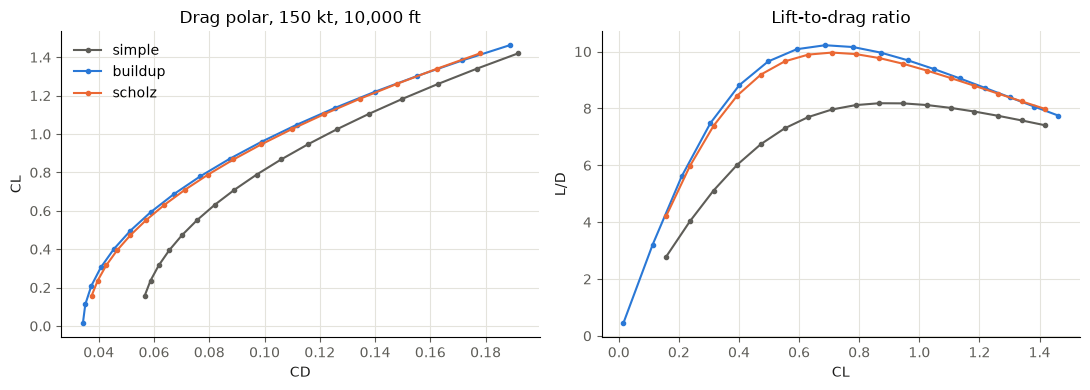

simple   at CL 0.6: CD 0.0795, CD0 0.0549, e 0.766, L/D 7.55
buildup  at CL 0.6: CD 0.0594, CD0 0.0349, e 0.766, L/D 10.10
scholz   at CL 0.6: CD 0.0612, CD0 0.0357, e 0.737, L/D 9.81
PASS  AeroBuildup and Scholz CD within 10 % at CL 0.6
PASS  both build-ups below SimpleAerodynamics with the guessed 0.8 m2
PASS  polars monotonic: CD rises with CL above CL 0.2


In [5]:
altitude_m, velocity_m_s = 10000 * u.foot, 150 * u.knot
alphas = np.linspace(-2, 14, 17)
polars = {}
for name, aero in models.items():
    t0 = time.time()
    results = [aero.evaluate(aircraft, velocity_m_s, altitude_m, a) for a in alphas]
    polars[name] = dict(cl=np.array([scalar(r.cl) for r in results]), cd=np.array([scalar(r.cd) for r in results]),
                        cd0=np.array([scalar(r.cd0) for r in results]),
                        e=np.array([scalar(r.oswald_efficiency) for r in results]))
    print(f"{name:8s} {1e3 * (time.time() - t0) / len(alphas):6.1f} ms per point")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, p in polars.items():
    axes[0].plot(p["cd"], p["cl"], color=colors[name], marker="o", ms=3, label=name)
    axes[1].plot(p["cl"], p["cl"] / p["cd"], color=colors[name], marker="o", ms=3, label=name)
axes[0].set(xlabel="CD", ylabel="CL", title="Drag polar, 150 kt, 10,000 ft")
axes[1].set(xlabel="CL", ylabel="L/D", title="Lift-to-drag ratio")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

def at_cl(name, cl_target, key):
    p = polars[name]
    return float(np.interp(cl_target, p["cl"], p[key]))

cl_cruise = 0.6
for name in models:
    cd = at_cl(name, cl_cruise, "cd")
    print(f"{name:8s} at CL {cl_cruise}: CD {cd:.4f}, CD0 {at_cl(name, cl_cruise, 'cd0'):.4f}, "
          f"e {at_cl(name, cl_cruise, 'e'):.3f}, L/D {cl_cruise / cd:.2f}")
check("AeroBuildup and Scholz CD within 10 % at CL 0.6",
      abs(at_cl("buildup", cl_cruise, "cd") / at_cl("scholz", cl_cruise, "cd") - 1) < 0.10)
check("both build-ups below SimpleAerodynamics with the guessed 0.8 m2",
      at_cl("buildup", cl_cruise, "cd") < at_cl("simple", cl_cruise, "cd")
      and at_cl("scholz", cl_cruise, "cd") < at_cl("simple", cl_cruise, "cd"))
check("polars monotonic: CD rises with CL above CL 0.2",
      all(np.all(np.diff(p["cd"][p["cl"] > 0.2]) > 0) for p in polars.values()))

### 4. Drag breakdown at cruise

Component parasite drag at CL about 0.6 (AeroBuildup at the matching angle of attack). The 3.00 ft2
"fittings and fixtures" area is the XV-15 value from NDARC; it replaces the guessed 0.8 m2 (8.6 ft2), which was
almost the XV-15's whole drag area.

item               simple  buildup   scholz   (D/q ft2: buildup / scholz)
wing               0.0115   0.0096   0.0101    2.42 /  2.54
horizontal_tail    0.0022   0.0019   0.0023    0.49 /  0.56
vertical_tail      0.0010   0.0009   0.0010    0.23 /  0.26
fuselage           0.0060   0.0059   0.0065    1.49 /  1.64
nacelles           0.0000   0.0046   0.0038    1.14 /  0.94
miscellaneous      0.0343   0.0120   0.0120    3.00 /  3.00
total              0.0549   0.0349   0.0357    8.76 /  8.94


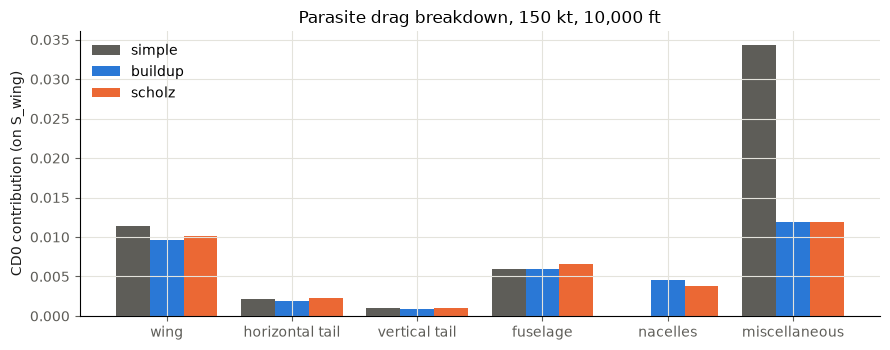

PASS  nacelle drag: AeroBuildup body x Q 1.5 within 35 % of Scholz (Raymer FF)
PASS  wing profile drag within 25 % (NeuralFoil, transition 10 % vs fully turbulent Cf x FF)


In [6]:
buildup = models["buildup"]
alpha_cruise = float(np.interp(cl_cruise, polars["buildup"]["cl"], alphas))
b_items = {i.label: scalar(i.cd0) for i in buildup.evaluate_buildup(aircraft, velocity_m_s, altitude_m,
                                                                   alpha_cruise).breakdown}
s_items = {i.label: scalar(i.cd0) for i in models["scholz"].parasite_drag_breakdown(aircraft, velocity_m_s, altitude_m)}
m_items = {i.label: scalar(i.cd0) for i in models["simple"].parasite_drag_breakdown(aircraft, velocity_m_s, altitude_m)}
labels = ["wing", "horizontal_tail", "vertical_tail", "fuselage", "nacelles", "miscellaneous"]
area_ft2 = aircraft.wing.area_m2 / u.foot**2
print(f"{'item':16s} {'simple':>8s} {'buildup':>8s} {'scholz':>8s}   (D/q ft2: buildup / scholz)")
for label in labels:
    print(f"{label:16s} {m_items.get(label, 0):8.4f} {b_items.get(label, 0):8.4f} {s_items.get(label, 0):8.4f}"
          f"   {b_items.get(label, 0) * area_ft2:5.2f} / {s_items.get(label, 0) * area_ft2:5.2f}")
totals = [sum(d.get(l, 0) for l in labels) for d in (m_items, b_items, s_items)]
print(f"{'total':16s} {totals[0]:8.4f} {totals[1]:8.4f} {totals[2]:8.4f}   {totals[1] * area_ft2:5.2f} / {totals[2] * area_ft2:5.2f}")

fig, ax = plt.subplots(figsize=(9, 3.6))
width = 0.27
x = np.arange(len(labels))
for k, (name, items) in enumerate((("simple", m_items), ("buildup", b_items), ("scholz", s_items))):
    ax.bar(x + (k - 1) * width, [items.get(l, 0) for l in labels], width, color=colors[name], label=name)
ax.set_xticks(x, [l.replace("_", " ") for l in labels])
ax.set(ylabel="CD0 contribution (on S_wing)", title="Parasite drag breakdown, 150 kt, 10,000 ft")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
check("nacelle drag: AeroBuildup body x Q 1.5 within 35 % of Scholz (Raymer FF)",
      abs(b_items["nacelles"] / s_items["nacelles"] - 1) < 0.35)
check("wing profile drag within 25 % (NeuralFoil, transition 10 % vs fully turbulent Cf x FF)",
      abs(b_items["wing"] / s_items["wing"] - 1) < 0.25)

### 5. XV-15 check against NDARC

Johnson (2010) Table 1 gives the XV-15 cruise drag area D/q = 9.25 ft2: fuselage 1.56, fuselage fittings and
fixtures 3.00, pylons 2 x 0.76, horizontal tail 0.63, vertical tail 0.36, wing 2.18. The components modelled
here (wing, tails, fuselage, nacelles) sum to 6.25 ft2. The XV-15 aircraft of Tier 10a with 9 ft x 3.3 ft tip
nacelles and an H-tail (Q = 1.08) is evaluated at its 200 kt / 20,000 ft cruise near zero lift.

In [7]:
xv = Xv15Reference()
xv15 = build_xv15_aircraft(xv, mass_engine_kg=300.0)
xv15 = replace(xv15, nacelles=replace(xv15.nacelles, length_m=9 * u.foot, diameter_m=3.3 * u.foot,
                                      y_m=xv15.wing.span_m() / 2))
h_tail = InterferenceFactors(horizontal_tail=1.08, vertical_tail=1.08)
ndarc = dict(wing=2.18, tails=0.99, fuselage=1.56, nacelles=1.52)
for name, aero in (("buildup", BuildupAerodynamics(interference=h_tail)),
                   ("scholz", ScholzAerodynamics(interference=h_tail))):
    if name == "buildup":
        items = aero.evaluate_buildup(xv15, xv.velocity_cruise_m_s, xv.altitude_cruise_m, 0.0).breakdown
    else:
        items = aero.parasite_drag_breakdown(xv15, xv.velocity_cruise_m_s, xv.altitude_cruise_m)
    d = {i.label: scalar(i.cd0) * xv15.wing.area_m2 / u.foot**2 for i in items}
    grouped = dict(wing=d["wing"], tails=d["horizontal_tail"] + d["vertical_tail"], fuselage=d["fuselage"],
                   nacelles=d["nacelles"])
    total = sum(grouped.values())
    print(f"{name:8s} " + ", ".join(f"{k} {v:.2f}" for k, v in grouped.items()) + f"; sum {total:.2f} ft2 "
          f"(NDARC 6.25), with 3.00 fittings {total + 3.0:.2f} (NDARC 9.25)")
    check(f"XV-15 component D/q ({name}) within 25 % of NDARC", abs(total / 6.25 - 1) < 0.25)

buildup  wing 1.60, tails 0.84, fuselage 1.37, nacelles 1.12; sum 4.94 ft2 (NDARC 6.25), with 3.00 fittings 7.94 (NDARC 9.25)
PASS  XV-15 component D/q (buildup) within 25 % of NDARC
scholz   wing 1.79, tails 1.02, fuselage 1.60, nacelles 0.93; sum 5.34 ft2 (NDARC 6.25), with 3.00 fittings 8.34 (NDARC 9.25)
PASS  XV-15 component D/q (scholz) within 25 % of NDARC


### 6. Blown wing

The rotor slipstream in airplane mode: momentum-theory induced velocity, its development to the wing
(`v_i (1 + x / sqrt(x^2 + R^2))`, x = 0.4 R), a contracted slipstream radius, and the ideal swirl
`T / (rho A Omega 2R/3)`. On the immersed span (half of each tip rotor's slipstream): the dynamic-pressure ratio
raises lift and profile drag; the swirl angle raises the local angle of attack (inboard-up rotation) and the wing
recovers half of the swirl kinetic-energy flux as thrust. All increments vanish at zero thrust.

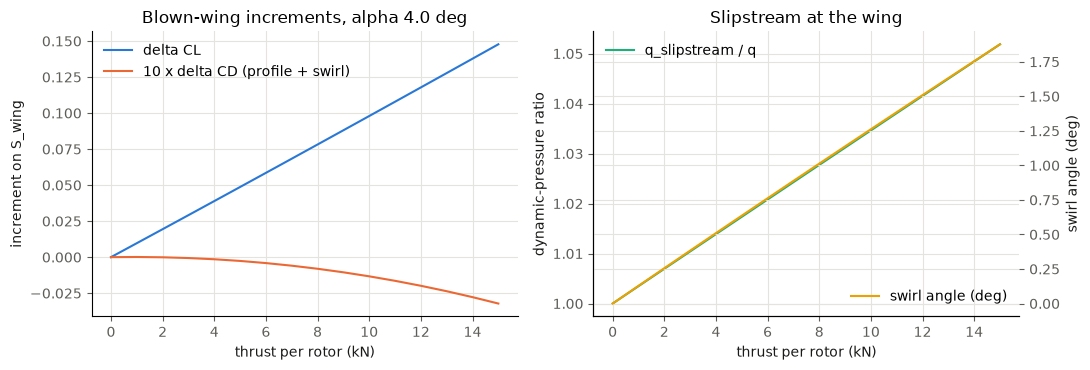

at the cruise thrust 1839 N per rotor: q ratio 1.0064, swirl 0.24 deg, immersed 18.8 m2 of 23.3, delta CL +0.0179, delta CD -0.00000
PASS  zero thrust: no increment
PASS  lift increment grows with thrust
PASS  profile increment (q ratio) positive and growing with thrust (~ T)
PASS  swirl recovery negative and growing faster (~ T^2): net drag falls at high thrust


In [8]:
alpha_blown = 4.0
speed_rotor_rad_s = 0.55 * reference.design.speed_tip_m_s / reference.radius_rotor_m
thrusts_N = np.linspace(0, 15000, 16)
blown_aero = models["buildup"]
rows = [blown_aero.evaluate_buildup(aircraft, velocity_m_s, altitude_m, alpha_blown,
                                    rotor_state=RotorState(t, speed_rotor_rad_s)) for t in thrusts_N]
delta_cl = np.array([scalar(r.blown.delta_cl) for r in rows])
delta_cd = np.array([scalar(r.blown.delta_cd_profile + r.blown.delta_cd_swirl) for r in rows])
ratio_q = np.array([scalar(r.blown.ratio_dynamic_pressure) for r in rows])
swirl_deg = np.array([scalar(r.blown.angle_swirl_deg) for r in rows])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(thrusts_N / 1e3, delta_cl, color=blue, label="delta CL")
axes[0].plot(thrusts_N / 1e3, 10 * delta_cd, color=orange, label="10 x delta CD (profile + swirl)")
axes[0].set(xlabel="thrust per rotor (kN)", ylabel="increment on S_wing", title=f"Blown-wing increments, alpha {alpha_blown} deg")
axes[0].legend(frameon=False)
axes[1].plot(thrusts_N / 1e3, ratio_q, color=aqua, label="q_slipstream / q")
ax2 = axes[1].twinx()
ax2.plot(thrusts_N / 1e3, swirl_deg, color=yellow, label="swirl angle (deg)")
axes[1].set(xlabel="thrust per rotor (kN)", ylabel="dynamic-pressure ratio", title="Slipstream at the wing")
ax2.set_ylabel("swirl angle (deg)")
axes[1].legend(loc="upper left", frameon=False); ax2.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()
cruise_thrust_N = 0.5 * scalar(blown_aero.evaluate(aircraft, velocity_m_s, altitude_m, alpha_blown).drag_N)
cruise_row = blown_aero.evaluate_buildup(aircraft, velocity_m_s, altitude_m, alpha_blown,
                                         rotor_state=RotorState(cruise_thrust_N, speed_rotor_rad_s))
print(f"at the cruise thrust {cruise_thrust_N:.0f} N per rotor: q ratio {scalar(cruise_row.blown.ratio_dynamic_pressure):.4f}, "
      f"swirl {scalar(cruise_row.blown.angle_swirl_deg):.2f} deg, immersed {scalar(cruise_row.blown.area_immersed_m2):.1f} m2 "
      f"of {aircraft.wing.area_m2:.1f}, delta CL {scalar(cruise_row.blown.delta_cl):+.4f}, delta CD "
      f"{scalar(cruise_row.blown.delta_cd_profile + cruise_row.blown.delta_cd_swirl):+.5f}")
check("zero thrust: no increment", abs(delta_cl[0]) < 1e-12 and abs(delta_cd[0]) < 1e-12)
check("lift increment grows with thrust", np.all(np.diff(delta_cl) > 0))
swirl_cd = np.array([scalar(r.blown.delta_cd_swirl) for r in rows])
profile_cd = np.array([scalar(r.blown.delta_cd_profile) for r in rows])
check("profile increment (q ratio) positive and growing with thrust (~ T)", np.all(np.diff(profile_cd) > 0))
check("swirl recovery negative and growing faster (~ T^2): net drag falls at high thrust",
      np.all(np.diff(swirl_cd) < 0) and delta_cd[-1] < 0)

### 7. Hover download from geometry

`DL/T = C_D,v S_immersed / A_disk` with the fully developed wake (NDARC), the immersed strip under the inboard
half of each contracted wake (radius R/sqrt 2), and the flap-projected chord. C_D,v = 0.846 reproduces the
XV-15's 7 % with flaps; the Halo reference geometry gives about the same.

download: XV-15 0.0700, Halo reference 0.0673 (constant 0.07 in SimpleAerodynamics)
PASS  XV-15 calibration reproduces 0.07


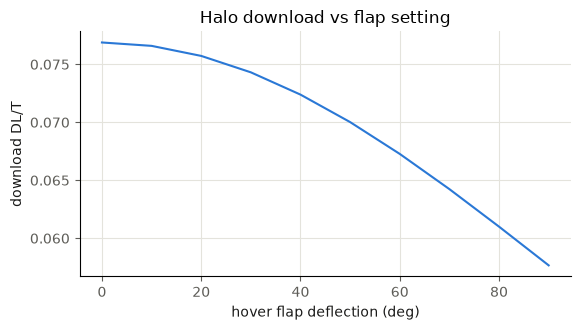

PASS  flap deflection lowers download


In [9]:
xv15_chord_m = 168.88 / 32.17 * u.foot
dl_xv15 = scalar(download_fraction(xv15_chord_m, 12.5 * u.foot, 2))
dl_halo = scalar(models["buildup"].hover_download_fraction(aircraft))
print(f"download: XV-15 {dl_xv15:.4f}, Halo reference {dl_halo:.4f} (constant 0.07 in SimpleAerodynamics)")
check("XV-15 calibration reproduces 0.07", abs(dl_xv15 - 0.07) < 2e-4)
flaps = np.linspace(0, 90, 10)
chord_m = aircraft.wing.area_m2 / scalar(aircraft.wing.span_m())
dl_flap = [scalar(download_fraction(chord_m, reference.radius_rotor_m, 2, HoverDownload(deflection_flap_hover_deg=f)))
           for f in flaps]
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(flaps, dl_flap, color=blue)
ax.set(xlabel="hover flap deflection (deg)", ylabel="download DL/T", title="Halo download vs flap setting")
plt.tight_layout()
plt.show()
check("flap deflection lowers download", np.all(np.diff(dl_flap) < 0))

## 2. Proprotor calibrated on the full-scale JVX test

*From `tier12_rotor_physics/rotor_physics_verification.ipynb`.*

In [10]:
import sys
from dataclasses import replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

from examples.halo_sizing import (HaloAssumptions, assumptions_tier11a, assumptions_tier12, requirements_tier10c,
                                  solve_halo_sizing)
from examples.jvx_rotor_calibration import calibration_report, jvx_rotor, load_airplane, load_hover, predict

check_log = globals().get("check_log", [])


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
palette = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})

# Plan 022 made the 780 kg equivalent-circuit pack the reference; this notebook keeps reproducing its own tier
# (900 kg, constant-OCV battery).
from functools import partial
from examples.halo_sizing import HaloAssumptions as _HaloAssumptions, HaloRequirements as _HaloRequirements
from examples.halo_sizing import solve_halo_sizing as _solve_halo_sizing
HaloAssumptions = partial(_HaloAssumptions, drag_corrections=False, redundancy=False, machine_mass_model="torque_density", gearbox_stages=False,
                          battery_model="constant", wing_weight_model="raymer",
                          aerodynamics_model="simple", thermal_model=False)
HaloRequirements = partial(_HaloRequirements, mass_payload_kg=900.0)
solve_halo_sizing = partial(_solve_halo_sizing, requirements=HaloRequirements(), assumptions=HaloAssumptions())

### 1. Calibration

The fits are linear least squares in the drag terms. kappa is fixed at 1.15,
because free fits put it below 1: the induced term (CT^1.5) and the loading
term (CT^2) are collinear over the test range. The Mtip 0.73 hover points
are held out of the fit as a check.

In [11]:
report = calibration_report()
print(f"hover polar (d0, d1, d2) = {tuple(round(float(c), 5) for c in report.polar)}")
print(f"airplane increment (a, b) = {tuple(round(float(c), 5) for c in report.increment)}")
print(f"hover FM RMS {report.hover_fm_rms:.4f}; Mtip 0.73 power error max {report.hover_d2_power_error_max:.4f}")
print(f"airplane efficiency RMS {report.airplane_eta_rms:.4f}, max {report.airplane_eta_max:.4f}")
check("hover figure-of-merit RMS error below 0.015", report.hover_fm_rms < 0.015)
check("held-out Mtip 0.73 hover power within 3 %", report.hover_d2_power_error_max < 0.03)
check("airplane-mode efficiency RMS below 0.015, max below 0.04",
      report.airplane_eta_rms < 0.015 and report.airplane_eta_max < 0.04)
bucket = -report.polar[1] / (2 * report.polar[2])
check("drag bucket at a physical blade loading (CT/sigma 0.05-0.15)", 0.05 < bucket < 0.15)

hover polar (d0, d1, d2) = (0.0185, -0.22164, 1.06625)
airplane increment (a, b) = (0.00169, 0.01876)
hover FM RMS 0.0123; Mtip 0.73 power error max 0.0216
airplane efficiency RMS 0.0128, max 0.0363
PASS  hover figure-of-merit RMS error below 0.015
PASS  held-out Mtip 0.73 hover power within 3 %
PASS  airplane-mode efficiency RMS below 0.015, max below 0.04
PASS  drag bucket at a physical blade loading (CT/sigma 0.05-0.15)


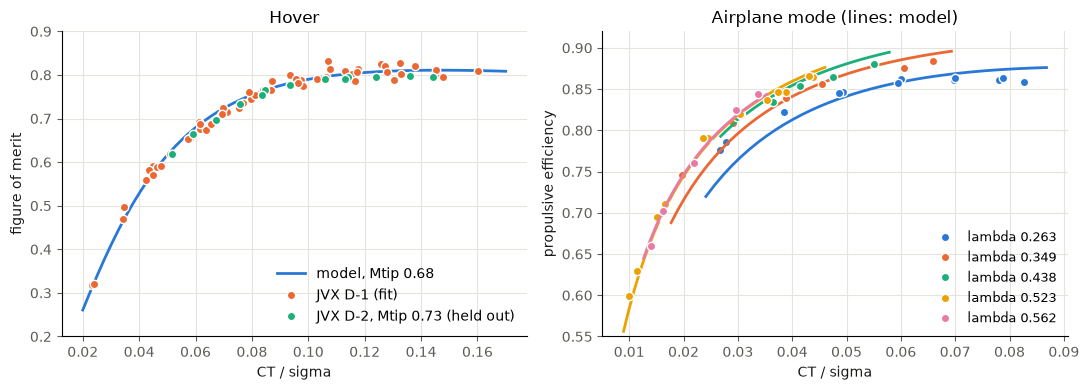

In [12]:
hover, airplane = load_hover(), load_airplane()
rotor = jvx_rotor(report.polar, report.increment)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
loads = np.linspace(0.02, 0.17, 60)
axes[0].plot(loads, [predict(rotor, x, 0.0, 0.68)[1] for x in loads], color=palette[0], lw=2, label="model, Mtip 0.68")
for table, color, label in (("D-1", palette[1], "JVX D-1 (fit)"), ("D-2", palette[2], "JVX D-2, Mtip 0.73 (held out)")):
    m = np.array([t == table for t in hover.table])
    axes[0].plot(hover.blade_loading[m], hover.figure_of_merit[m], "o", color=color, ms=6, mec="white", mew=1, label=label)
axes[0].set(xlabel="CT / sigma", ylabel="figure of merit", title="Hover", ylim=(0.2, 0.9))
axes[0].legend(frameon=False, loc="lower right")
for i, lam in enumerate((0.263, 0.349, 0.438, 0.523, 0.562)):
    m = np.abs(airplane.advance_ratio - lam) < 0.012
    xs = np.linspace(airplane.blade_loading[m].min() * 0.9, airplane.blade_loading[m].max() * 1.05, 40)
    axes[1].plot(xs, [predict(rotor, x, lam, 0.58)[1] for x in xs], color=palette[i], lw=2)
    axes[1].plot(airplane.blade_loading[m], airplane.efficiency[m], "o", color=palette[i], ms=6, mec="white", mew=1,
                 label=f"lambda {lam}")
axes[1].set(xlabel="CT / sigma", ylabel="propulsive efficiency", title="Airplane mode (lines: model)", ylim=(0.55, 0.92))
axes[1].legend(frameon=False, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

### 2. What rotor speed does now, and the limitation

At a fixed thrust, slowing the rotor cuts profile power, which scales as
Omega^3. In hover, blade loading pushes back: loading rises as 1/Omega^2, up
the drag polar. In airplane mode the loading reference (1 + 3 lambda^2) makes
the blades look lightly loaded, and the model has no blade-stall physics. So
cruise power keeps falling as the rotor slows, all the way out of the
calibrated range.

`advance_ratio_max` = 0.60 (the JVX data reach 0.56) is therefore a validity
bound. In sizing, that bound, not the physics, sets cruise rotor speed. BEM
with stall is the remedy, deferred to a later tier.

PASS  inside the validity bound, cruise power falls monotonically as the rotor slows


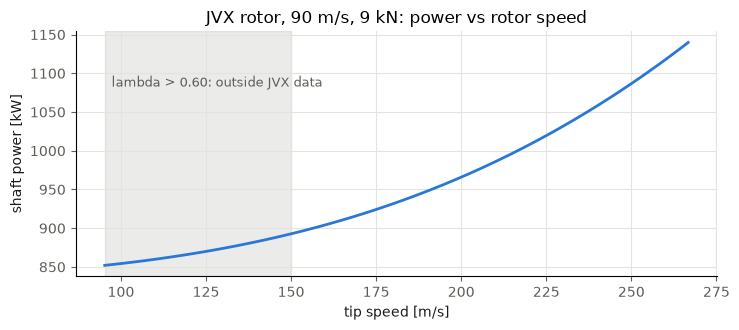

In [13]:
cruise = rotor.in_airplane_mode()
sea = asb.Atmosphere(altitude=0)
speeds = np.linspace(25, 70, 60)
radius = float(cruise.radius_m())
powers = np.array([float(cruise.evaluate(90.0, sea, thrust_N=9000.0, speed_rad_s=s).shaft_power_W) for s in speeds])
lam = 90.0 / (speeds * radius)
valid = lam <= cruise.advance_ratio_max
check("inside the validity bound, cruise power falls monotonically as the rotor slows",
      np.all(np.diff(powers[valid]) > 0))
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(speeds * radius, powers / 1e3, color=palette[0], lw=2)
ax.axvspan(speeds[0] * radius, 90.0 / cruise.advance_ratio_max, color=ink_muted, alpha=0.12)
ax.text(speeds[0] * radius + 2, powers.max() / 1e3 * 0.95, "lambda > 0.60: outside JVX data", color=ink_muted, fontsize=9)
ax.set(xlabel="tip speed [m/s]", ylabel="shaft power [kW]", title="JVX rotor, 90 m/s, 9 kN: power vs rotor speed")
plt.tight_layout()
plt.show()

## 3. The simple aerodynamic model

*From `tier5_aerodynamics/aerodynamics_verification.ipynb`.*

In [14]:
import ast
import sys
from dataclasses import replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import casadi as cas
import matplotlib.pyplot as plt

from aircraft_closure.aerodynamics.simple import DragIncrement, SimpleAerodynamics
from examples.aircraft_mass_closure import acceleration_gravity_m_s2, build_reference_aircraft, solve_mass_closure
from examples.cruise_closure import solve_cruise_closure

check_log = globals().get("check_log", [])


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


def close(a, b, rel=1e-9, abs_tol=1e-12):
    return abs(a - b) <= max(rel * abs(b), abs_tol)


aircraft = build_reference_aircraft(3.23)
aero = SimpleAerodynamics()
velocity_m_s, altitude_m = 60.0, 1000.0
ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})

### 1. Lift

The lift curve passes through zero at $\alpha_{0L}$ (-4 deg, an illustrative value
for a 4 %-cambered section), its slope is AeroSandbox's 3D ratio times $2\pi$,
below $2\pi$ and rising with aspect ratio, and the stall angle is where the
linear curve reaches $C_{L,max}$ (a caller-side bound; no post-stall model).

In [15]:
alpha_deg = np.linspace(-6, 16, 89)
cl = np.array([float(aero.evaluate(aircraft, velocity_m_s, altitude_m, a).cl) for a in alpha_deg])
slope = float(aero.lift_curve_slope_per_rad(aircraft, velocity_m_s, altitude_m))
alpha_stall_deg = float(aero.alpha_stall_deg(aircraft, velocity_m_s, altitude_m))
print(f"CL_alpha = {slope:.4f} /rad ({slope * np.pi / 180:.4f} /deg), stall at {alpha_stall_deg:.2f} deg")
check("lift: CL = 0 at the zero-lift angle", abs(float(aero.evaluate(aircraft, velocity_m_s, altitude_m, -4.0).cl)) < 1e-12)
check("lift: constant slope (linear model)", np.ptp(np.diff(cl)) < 1e-12)
check("lift: 3D slope below 2 pi", slope < 2 * np.pi)
slopes = [float(aero.lift_curve_slope_per_rad(replace(aircraft, wing=replace(aircraft.wing, aspect_ratio=a)),
                                              velocity_m_s, altitude_m)) for a in (6, 9, 12)]
check("lift: slope rises with aspect ratio", slopes[0] < slopes[1] < slopes[2])
check("lift: CL at the stall angle equals CLmax",
      close(float(aero.evaluate(aircraft, velocity_m_s, altitude_m, alpha_stall_deg).cl), aero.cl_max))

CL_alpha = 5.0230 /rad (0.0877 /deg), stall at 13.11 deg
PASS  lift: CL = 0 at the zero-lift angle
PASS  lift: constant slope (linear model)
PASS  lift: 3D slope below 2 pi
PASS  lift: slope rises with aspect ratio
PASS  lift: CL at the stall angle equals CLmax


### 2. Parasite drag buildup

Each component contributes $C_f\,FF\,Q\,S_{wet}/S_{ref}$ with its own Reynolds
number (MAC for surfaces, length for the fuselage). The miscellaneous drag area
(0.25 m2) stands for fixed gear, nacelles and stowed rotors, which this tier does
not model individually; it dominates $C_{D0}$, which is typical of fixed-gear
tiltrotor-like layouts but is an assumption, not a calibration.

wing            0.00980  (25.5 %)
horizontal_tail 0.00184  ( 4.8 %)
vertical_tail   0.00117  ( 3.1 %)
fuselage        0.00476  (12.4 %)
miscellaneous   0.02083  (54.2 %)
total           0.03840
PASS  parasite: CD0 equals the sum of the breakdown
PASS  parasite: miscellaneous item = CDA / S_ref
PASS  parasite: skin-friction terms fall with airspeed (Reynolds number)


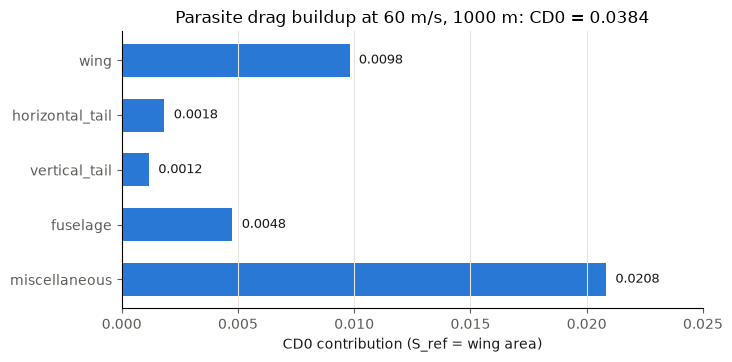

In [16]:
breakdown = aero.parasite_drag_breakdown(aircraft, velocity_m_s, altitude_m)
cd0 = sum(float(i.cd0) for i in breakdown)
for item in breakdown:
    print(f"{item.label:<16}{float(item.cd0):.5f}  ({100 * float(item.cd0) / cd0:4.1f} %)")
print(f"{'total':<16}{cd0:.5f}")
check("parasite: CD0 equals the sum of the breakdown",
      close(float(aero.evaluate(aircraft, velocity_m_s, altitude_m, 2.0).cd0), cd0))
check("parasite: miscellaneous item = CDA / S_ref", close(float(breakdown[-1].cd0), 0.25 / 12.0))
check("parasite: skin-friction terms fall with airspeed (Reynolds number)",
      float(aero.evaluate(aircraft, 80, altitude_m, 2.0).cd0) < float(aero.evaluate(aircraft, 40, altitude_m, 2.0).cd0))

labels = [i.label for i in breakdown][::-1]
values = [float(i.cd0) for i in breakdown][::-1]
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.barh(labels, values, color=blue, height=0.6)
for y, v in enumerate(values):
    ax.text(v + 0.0004, y, f"{v:.4f}", va="center", fontsize=9, color=ink)
ax.set(xlabel="CD0 contribution (S_ref = wing area)", xlim=(0, max(values) * 1.2),
       title=f"Parasite drag buildup at {velocity_m_s:.0f} m/s, {altitude_m:.0f} m: CD0 = {cd0:.4f}")
ax.grid(axis="y", visible=False)
plt.show()

### 3. Drag polar and maximum lift-to-drag

With a parabolic polar, $C_D - C_{D0} = C_L^2/(\pi e AR)$ and the maximum
$L/D = \tfrac12\sqrt{\pi e AR / C_{D0}}$ occurs at $C_L^* = \sqrt{C_{D0}\pi e AR}$.

Oswald e = 0.7600, CL* = 0.9084, (L/D)max = 11.828
PASS  polar: CD - CD0 = CL^2 / (pi e AR)
PASS  polar: L/D at CL* equals the closed-form maximum
PASS  polar: L/D lower either side of CL*
PASS  hook: drag increments add to CD


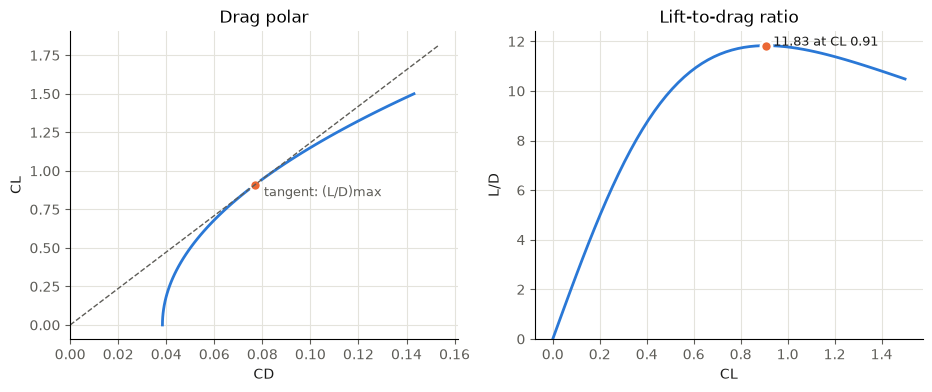

In [17]:
result = aero.evaluate(aircraft, velocity_m_s, altitude_m, 0.0)
cd0, e, aspect_ratio = float(result.cd0), float(result.oswald_efficiency), aircraft.wing.aspect_ratio
cl_star = np.sqrt(cd0 * np.pi * e * aspect_ratio)
lift_to_drag_max = 0.5 * np.sqrt(np.pi * e * aspect_ratio / cd0)
alpha_star_deg = aero.alpha_zero_lift_deg + np.degrees(cl_star / float(result.cl_alpha_per_rad))
best = aero.evaluate(aircraft, velocity_m_s, altitude_m, alpha_star_deg)
print(f"Oswald e = {e:.4f}, CL* = {cl_star:.4f}, (L/D)max = {lift_to_drag_max:.3f}")
check("polar: CD - CD0 = CL^2 / (pi e AR)", all(
    close(float(r.cd - r.cd0), float(r.cl**2 / (np.pi * e * aspect_ratio)))
    for r in (aero.evaluate(aircraft, velocity_m_s, altitude_m, a) for a in (-2, 3, 8))))
check("polar: L/D at CL* equals the closed-form maximum", close(float(best.lift_to_drag), lift_to_drag_max, rel=1e-9))
check("polar: L/D lower either side of CL*", all(
    float(aero.evaluate(aircraft, velocity_m_s, altitude_m, alpha_star_deg + d).lift_to_drag) < lift_to_drag_max
    for d in (-1, 1)))
check("hook: drag increments add to CD", close(float(aero.evaluate(
    aircraft, velocity_m_s, altitude_m, 3.0, (DragIncrement("probe", 0.003),)).cd - aero.evaluate(
    aircraft, velocity_m_s, altitude_m, 3.0).cd), 0.003))

polar = [aero.evaluate(aircraft, velocity_m_s, altitude_m, a) for a in np.linspace(-4, alpha_stall_deg, 60)]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot([float(r.cd) for r in polar], [float(r.cl) for r in polar], color=blue, lw=2)
ax1.plot([float(best.cd)], [float(best.cl)], "o", color=orange, ms=8, mec="white", mew=2)
ax1.plot([0, 2 * float(best.cd)], [0, 2 * float(best.cl)], color=ink_muted, lw=1, ls="--")
ax1.text(float(best.cd) * 1.05, float(best.cl) * 0.92, "tangent: (L/D)max", color=ink_muted, fontsize=9)
ax1.set(xlabel="CD", ylabel="CL", xlim=(0, None), title="Drag polar")
ax2.plot([float(r.cl) for r in polar], [float(r.lift_to_drag) for r in polar], color=blue, lw=2)
ax2.plot([cl_star], [lift_to_drag_max], "o", color=orange, ms=8, mec="white", mew=2)
ax2.text(cl_star + 0.03, lift_to_drag_max, f"{lift_to_drag_max:.2f} at CL {cl_star:.2f}", fontsize=9, color=ink)
ax2.set(xlabel="CL", ylabel="L/D", ylim=(0, None), title="Lift-to-drag ratio")
plt.show()

### 4. Comparison with AeroSandbox `AeroBuildup`

`AeroBuildup` is AeroSandbox's higher-fidelity buildup on the same `asb.Airplane`.
It includes tail lift and its own drag submodels but not the miscellaneous drag
area, so agreement is expected in order of magnitude only. The comparison is
reported, not tuned: the simple model stays the simplest useful model, and
`AeroBuildup` is the natural next-fidelity source (architecture: intended aero
source 2).

In [18]:
alphas = np.array([0.0, 2.0, 4.0, 6.0])
ours = [aero.evaluate(aircraft, velocity_m_s, altitude_m, a) for a in alphas]
native = [asb.AeroBuildup(airplane=aircraft.to_asb(), op_point=asb.OperatingPoint(
    atmosphere=asb.Atmosphere(altitude=altitude_m), velocity=velocity_m_s, alpha=a)).run() for a in alphas]
slope_ours = float(np.polyfit(alphas, [float(r.cl) for r in ours], 1)[0])
slope_native = float(np.polyfit(alphas, [float(np.ravel(r["CL"])[0]) for r in native], 1)[0])
cd_native_0 = float(np.ravel(native[0]["CD"])[0])
print(f"lift slope per deg: simple {slope_ours:.4f}, AeroBuildup (with tails) {slope_native:.4f}")
print(f"CD at 0 deg: simple {float(ours[0].cd):.4f} (incl. misc {0.25 / 12:.4f}), AeroBuildup {cd_native_0:.4f}")
check("comparison: wing-only slope below AeroBuildup's whole-aircraft slope (tail lift is Tier 6)", slope_ours < slope_native)
check("comparison: slopes within 30 % (order agreement)", abs(slope_ours / slope_native - 1) < 0.30)
check("comparison: CD0 without misc area within a factor 2 of AeroBuildup",
      0.5 < (float(ours[0].cd) - 0.25 / 12) / cd_native_0 < 2.0)

lift slope per deg: simple 0.0877, AeroBuildup (with tails) 0.1052
CD at 0 deg: simple 0.0441 (incl. misc 0.0208), AeroBuildup 0.0235
PASS  comparison: wing-only slope below AeroBuildup's whole-aircraft slope (tail lift is Tier 6)
PASS  comparison: slopes within 30 % (order agreement)
PASS  comparison: CD0 without misc area within a factor 2 of AeroBuildup


## Summary

In [19]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} of {len(check_log)} checks passed")
for name in failed:
    print("FAILED:", name)

39 of 39 checks passed
